In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import norm
from sklearn.metrics import matthews_corrcoef, confusion_matrix
from matplotlib import font_manager
import cobra
import sys
import os
import pandas as pd
import numpy as np
sys.path.append('../')
from modelfunctions import *

# use Arial
try: 
    font_path = '/home/emil/.fonts/ARIAL.TTF'  # Your font path goes here
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = prop.get_name()
except:
    print('Arial font not found, using default')

wd = os.path.abspath(os.getcwd()).removesuffix('Code/validation')
figdir = wd + 'Figures/'

cols_opt_order = [(r/0xff, g/0xff, b/0xff) for r,g,b in [(0x67, 0x19, 0x70),
 (0xee, 0x96, 0x4b), (0x0, 0x6d, 0x6f), (0xb6, 0xd0, 0x94), (0xe5, 0x62, 0x5e),
 (0xff, 0xbf, 0xa0), (0x66, 0x0, 0x0), (0xab, 0x81, 0xcd), (0x29, 0x70, 0x45),
 (0xba, 0xde, 0xfc)]]
ix1, ix2 = 3, 8
cdict2 = {'red':   [(0.0,  0.0, cols_opt_order[ix1][0]),
                   (1.0,  cols_opt_order[ix2][0], 1.0)],
         'green': [(0.0,  0.0, cols_opt_order[ix1][1]),
                  (1.0,  cols_opt_order[ix2][1], 1.0)],
         'blue':  [(0.0,  0.0, cols_opt_order[ix1][2]),
                  (1.0,  cols_opt_order[ix2][2], 1.0)]} 
my_green = mpl.colors.LinearSegmentedColormap('my_green',cdict2,256)

In [2]:
# functions to assess Matthews correlation coefficient and corresponding p-values

# macro-average MCC as defined in https://doi.org/10.48550/arXiv.2503.06450
def mamcc(y_true, y_pred):
    C = confusion_matrix(y_true, y_pred)
    r = C.shape[0]
    N = C.sum()
    res = 0
    for i in range(r):
        TP = C[i,i]
        FP = sum(C[j, i] for j in range(r) if i != j)
        FN = sum(C[i, j] for j in range(r) if i != j)
        TN = N - TP - FP - FN
        o = TP * TN - FP * FN
        u = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
        res += (o / u)

    return res / r

def permutation_test(y_true, y_pred, corr_f, n_permutations=10000, alpha = None, epsilon = None):
# corr_f: a funciton to calculate the correlation

    if alpha is not None or epsilon is not None:
        if alpha is None or epsilon is None:
            print('Error: alpha (significance level) and epsilon (bound on probability of error of Monte-Carlo) both have to be provided')
            return 0, 1
        stopping = True
        z = norm.ppf(1 - epsilon / 2)        

    # Calculate the observed MCC
    observed_mcc = corr_f(y_true, y_pred)
    
    permutation_mccs = []
    curr_sum = 0

    for i in range(n_permutations):
        # Shuffle the true labels
        y_true_permuted = np.random.permutation(y_true)
        
        # Calculate MCC for the shuffled labels
        permuted_mcc = corr_f(y_true_permuted, y_pred)
        permutation_mccs.append(permuted_mcc)
        curr_sum += (permuted_mcc >= observed_mcc)

        if stopping:
            p_hat = curr_sum  / (i+1)
            upper_lim = p_hat + z * np.sqrt((alpha * (1-alpha)) / (i + 1))
            if upper_lim < alpha:
                break
    
    # Calculate the p-value as the proportion of permuted MCCs greater than or equal to the observed MCC
    p_value = curr_sum / (i + 1)

    if stopping and (i+1) == n_permutations:
        print('Warning: desired level of confidence not reached')
    
    return observed_mcc, p_value, i+1

def permutation_test_mcc(y_true, y_pred, n_permutations=10000, alpha = None, epsilon = None):
    return permutation_test(y_true, y_pred, matthews_corrcoef, n_permutations, alpha, epsilon)

def permutation_test_mamcc(y_true, y_pred, n_permutations=10000, alpha = None, epsilon = None):
    return permutation_test(y_true, y_pred, mamcc, n_permutations, alpha, epsilon)

## KO of chloroplastic genes

In [3]:
# gathered data by taking screenshots of Scharff and Bock 2014, extracting as text, and verifying manually 
df = pd.read_csv(wd + 'Data/analysis/KOCompare/KO_data_Scharff_Bock.csv')

# this list of chloroplast-encoded genes that the pcm does contain was manually checked
with open(wd + 'Data/analysis/KOCompare/enzymatic_chl_genes.txt', 'r') as file:
    enzymatic_genes = [line.strip() for line in file]

In [4]:
# Read the tobacco pcm plugged into AraCore
nita = cobra.io.read_sbml_model(f'{wd}Data/pcm/pluggedIntoAraCore/AraCore.Nicotiana_tabacum.pcm.xml')
nita_model_genes = [g.id for g in nita.genes]

# To convert between gene identifiers from PCM and the experimental data, gather the annotation in the fasta file
id2gene = {}
with open(f'{wd}Data/sequences/Nicotiana_tabacum.fasta', 'r') as file:
    for line in file:
        if line.startswith('>') and '[gene=' in line:
            words = line.split()
            if words[0].startswith('>lcl|'):
                curr_name = words[0].removeprefix('>lcl|')
            else:
                curr_name = words[0].removeprefix('>')
            for word in words[1:]:
                if word.startswith('[gene='):
                    id2gene[curr_name] = word.removeprefix('[gene=').removesuffix(']')
                    break

gene2ids = {}
for ncbi_id, gene in id2gene.items():
    gene2ids[gene] = gene2ids.get(gene, []) + [ncbi_id]

# Add it as a new column to the dataframe with experimental data
df['nita_gene'] = df['Gene'].apply(lambda s: '; '.join('; '.join(gene2ids.get(gene, ['NA'])) for gene in s.split('/')).split('; '))
df = df.explode('nita_gene')

Set parameter Username
Set parameter LicenseID to value 2694489
Academic license - for non-commercial use only - expires 2026-08-08


In [5]:
# Perform simulation
c = 0
res = {}

media = pd.read_csv(f'{wd}Data/analysis/simulationMedia.tsv', sep='\t')

for cond in ['hetero_suc', 'hetero_str', 'photo']:
    # Put pcm into respective conditions
    for rid, ub in zip(media['rxn'], media[cond]):
        try:
            get_rid(nita, rid).upper_bound = ub
        except KeyError:
            continue

    # perform simulation
    res[cond] = {}
    wt_res = nita.slim_optimize()
    for i, gene in enumerate(enzymatic_genes):
        any_gene_there = False
        nita_genes = df.loc[df['Gene'] == gene, 'nita_gene'].to_list()
        if nita_genes and nita_genes != ['NA']:
            with nita:
                for nita_gene in nita_genes:
                    if nita_gene in nita_model_genes:
                        get_gid(nita, nita_gene).knock_out()                
            
                sim_res = 1 - round(nita.slim_optimize() / wt_res, 5)
                res[cond][gene] = int(sim_res) if int(sim_res) == sim_res else sim_res
preds = pd.DataFrame(res)

full_df = df.join(preds, on='Gene').loc[lambda df: ~df['photo'].isna()]

In [6]:
# format data for a heatmap
plot_df = full_df[['Gene', 'Essential for heterotrophic growth',
                   'hetero_str', 'Essential for autotrophic growth', 'photo']].copy()
plot_df.columns = ['Gene', 'Hetero Experimental', 'Hetero Predicted', 'Photo Experimental', 'Photo Predicted']

repdict = {'+': 1, '-': 0, '-/+': 0.5}
plot_df.loc[:, ['Hetero Experimental', 'Photo Experimental']] = \
    plot_df[['Hetero Experimental', 'Photo Experimental']].map(lambda x: repdict[x])
plot_df.drop_duplicates(inplace=True)
plot_df.head()

,Gene,Hetero Experimental,Hetero Predicted,Photo Experimental,Photo Predicted
0,psaA,0,0.0,1.0,1.0
1,psaB,0,0.0,1.0,1.0
2,psaC,0,0.0,1.0,1.0
3,psaI,0,0.0,0.0,1.0
4,psaJ,0,0.0,0.0,1.0


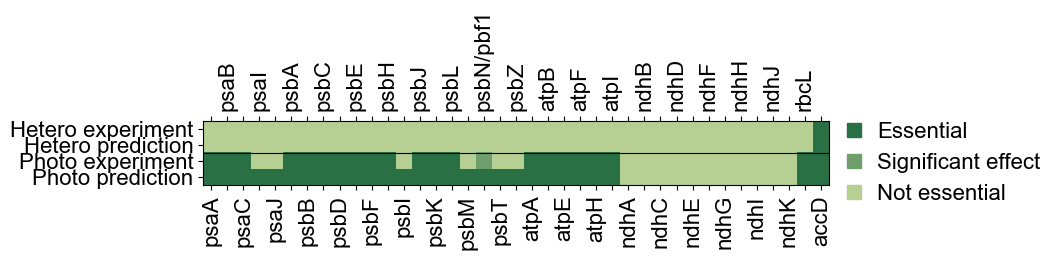

In [7]:
# heatmap, horizontal
experiment_dict = {'Hetero Experimental': 'Hetero experiment', 
                   'Hetero Predicted': 'Hetero prediction',
                   'Photo Experimental': 'Photo experiment',
                   'Photo Predicted': 'Photo prediction'}
legend_above = False

plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(12,12))

# order data according to clustering
data_cols = ['Hetero Experimental', 'Hetero Predicted', 'Photo Experimental', 'Photo Predicted']
data = plot_df[data_cols].astype(float).T

im = ax.imshow(data, cmap = my_green)
ax.hlines(1.5, -0.5, data.shape[1] - 0.5, 'k',
          lw=ax.spines['top'].get_linewidth())

#cbar = ax.figure.colorbar(im, ax=ax, shrink=0.7)
#cbar.ax.set_ylabel('Essential under given growth mode', rotation=-90, va="bottom")
if legend_above:
    ax.legend(bbox_to_anchor=(0.78, 1.5), frameon=False, 
            handles = [mpl.lines.Line2D([], [], marker = 's', linewidth=0, markersize=10, color=my_green(x)) for x in [1., 0.5, 0.]],
            labels=['Essential', 'KO has significant effect', 'Not essential'], ncols=3)
else:
    ax.legend(bbox_to_anchor=(1.37, 1.3), frameon=False, handletextpad = 0.04,
           handles = [mpl.lines.Line2D([], [], marker = 's', linewidth=0, markersize=10, color=my_green(x)) for x in [1., 0.5, 0.]],
           labels=['Essential', 'Significant effect', 'Not essential'], ncols=1,
           markerfirst = True)

# Show all ticks and label them with the respective list entries
ax.set_yticks(np.arange(data.shape[0]), labels=[experiment_dict[x] for x in data_cols])
ax.set_xticks(np.arange(data.shape[1]), labels=plot_df['Gene'])

# duplicate ticks to top
im.axes.tick_params(axis="x", bottom=True, top=True, labelbottom=True, labeltop=True)
# rotate top and bottom separately
plt.setp([tick.label1 for tick in im.axes.get_xaxis().get_major_ticks()], rotation=90,
         ha="right", va="center", rotation_mode="anchor")
plt.setp([tick.label2 for tick in im.axes.get_xaxis().get_major_ticks()], rotation=90,
         ha="left", va="center", rotation_mode="anchor")
# hide every second tick and label on top and bottom
plt.setp([tick.label1 for tick in im.axes.get_xaxis().get_major_ticks()[1::2]], visible=False)
#plt.setp([tick.tick1line for tick in im.axes.get_xaxis().get_major_ticks()[::2]], visible=False)
plt.setp([tick.label2 for tick in im.axes.get_xaxis().get_major_ticks()[::2]], visible=False)
#plt.setp([tick.tick2line for tick in im.axes.get_xaxis().get_major_ticks()[1::2]], visible=False)

ax.set_title("")
fig.tight_layout()
plt.savefig(figdir + 'ko_heatmap_horiz_nita.png', dpi = 300, transparent=True)
plt.show()
  
# Save data for analysis in geographic_analysis.ipynb
#pd.DataFrame(data, columns=acc_list, index=acc_list).to_csv(f'{wd}data/assemblies/functional_corr.csv')

In [8]:
# mcc with p-value estimation (Monte-Carlo, permutation test, takes a while!)
# consider the severe phenotype as non-essential result 
exp = np.floor(data.loc[[row for row in data.index if 'Experimental' in row]].to_numpy().flatten())  
pred = data.loc[[row for row in data.index if 'Predicted' in row]].to_numpy().flatten()

def p_str(p):
    if p <1e-3:
        return "{:.3e}".format(p)
    else:
        return round(p, 4)

alpha = 0.01
mcc, mcc_p, n_it = permutation_test_mcc(exp, pred, n_permutations=int(1e10), alpha = alpha, epsilon = 1e-4)
mam, mam_p, man_it = permutation_test_mamcc(exp, pred, n_permutations=int(1e10), alpha = alpha, epsilon = 1e-4)

print(f'The KO predictions have a Matthews correlation coefficient (MCC) of {round(mcc, 2)} (p < {p_str(alpha)}) with the experimental results.')
print(f'The KO predictions have a macro-averaged MCC (maM) of {round(mam, 2)} (p < {p_str(alpha)}) with the experimental results.')

The KO predictions have a Matthews correlation coefficient (MCC) of 0.81 (p < 0.01) with the experimental results.
The KO predictions have a macro-averaged MCC (maM) of 0.81 (p < 0.01) with the experimental results.


## KO of chloroplast-targeted genes

In [9]:
# embryo-deficient mutants
emb = pd.read_excel(f'{wd}Data/analysis/KOCompare/bryant_2011_supp/Table_S6_Final_Reduced.xls', header=[0,1])
emb = emb[['Locus', 'Gene Symbol', 'Statusa']]
emb.columns = ['Locus', 'Gene Symbol', 'Status']
emb = emb.loc[~emb['Status'].isna(), :]
emb['Phenotype Class'] = 'EMB'

# pigment-deficient mutants
pdp = pd.read_excel(f'{wd}Data/analysis/KOCompare/bryant_2011_supp/Table_S7_Final_Reduced.xls', header=[0,1])
pdp = pdp[['Locus', 'Symbol', 'Statusa', 'Phenotype Classb']]
pdp.columns = ['Locus', 'Gene Symbol', 'Status', 'Phenotype Class']
pdp = pdp.loc[~pdp['Status'].isna(), :]

# other phenotype mutants
oth = pd.read_excel(f'{wd}Data/analysis/KOCompare/bryant_2011_supp/Table_S8_Final_Reduced.xls', header=[0,1])
oth = oth[['Locus', 'Gene Symbol', 'Statusa', 'Mutant Phenotypeb']]
oth.columns = ['Locus', 'Gene Symbol', 'Status', 'Phenotype Class']
oth = oth.loc[~oth['Status'].isna(), :]

# concat
kodf = pd.concat([emb, pdp, oth], ignore_index=True)
kodf.head()

,Locus,Gene Symbol,Status,Phenotype Class
0,At3g10690,AtGYRA,C,EMB
1,At5g24120,SIG5,C,EMB
2,At1g30610,EMB2279,C,EMB
3,At1g59990,EMB3108,NC,EMB
4,At2g01860,EMB975,C,EMB


Explanation:
- Status: C = confirmed (by different web-lab methods), NC = not confirmed
- Phenotype Class:
    - EMB: embryo deficient (lethal)
    - V: not lethal; plant is pigment deficient
    - PDE: not lethal; embryo is pigment deficient
    - Morphological: plant has altered morphology
    - Molecular: plant has altered biochemical properties
    - Conditional: plant has a phenotype only under specific environmental conditions
    - Essential: lethal, but not in embryonic stage?


In [10]:
# formulate what these would mean for the model predictions
def class_model_res(phenotype_class):
    if phenotype_class in ['Essential', 'EMB']:
        return 'essential'
    elif phenotype_class in ['V', 'PDE']:
        return 'pigment-deficient'
    elif phenotype_class in ['Morphological', 'Molecular', 'Conditional']:
        return 'not essential'

kodf['exp model res'] = kodf['Phenotype Class'].apply(class_model_res)

In [11]:
# write genes to disk to run KO analysis on
with open(f'{wd}Data/analysis/KOCompare/nuc_genes.txt', 'w') as file:
    for gene in kodf['Locus'].unique():
        file.write(gene + '\n')

In [83]:
with silence():
    pcm = cobra.io.read_sbml_model(f'{wd}Data/pcm/species/Arabidopsis_thaliana.pcm.v2.xml')
    ara_genes = {g.id for g in pcm.genes if g.id.startswith('At')}

with open(f'{wd}Data/analysis/KOCompare/nuc_genes.txt', 'r') as file:
    genes = {line.strip() for line in file}

print(f'We have KO-information for {len(genes)} genes')
print(f'The Arabidopsis-specific model contains {len(ara_genes.intersection(genes))} genes with KO information')

We have KO-information for 378 genes
The Arabidopsis-specific model contains 156 genes with KO information


In [85]:
# Perform simulation
include_light_cond = True
c = 0

res_all, res_pigm, res_no_pigm = {}, {}, {}

# Put pcm into heterotrophic conditions
media = pd.read_csv(f'{wd}Data/analysis/simulationMedia.tsv', sep='\t')
night_pcm = pcm.copy()
for rid, ub in zip(media['rxn'], media['hetero_str']):
    get_rid(night_pcm, rid).upper_bound = ub

for rid, ub in zip(media['rxn'], media['photo']):
    get_rid(pcm, rid).upper_bound = ub

res_all['WT'] = min(pcm.slim_optimize(), night_pcm.slim_optimize())
res_pigm['WT'] = min(check_production(night_pcm, 'pPg[h]'), check_production(pcm, 'pPg[h]'))
with pcm:
    with night_pcm:
        r = cobra.Reaction(id='Im_tmp_pigm', name='import pigments tmp', lower_bound=0, upper_bound=1000)
        r.add_metabolites({night_pcm.metabolites.get_by_id('pPg[h]'): 1})
        night_pcm.add_reactions([r])

        r = cobra.Reaction(id='Im_tmp_pigm', name='import pigments tmp', lower_bound=0, upper_bound=1000)
        r.add_metabolites({pcm.metabolites.get_by_id('pPg[h]'): 1})
        pcm.add_reactions([r])
        res_no_pigm['WT'] = min(night_pcm.slim_optimize(), pcm.slim_optimize())

for i, gene in enumerate(genes):
    print(f'Processing gene {i+1}/{len(genes)}: {gene}', end = '                   \r')
    if gene.lower() in [g.id.lower() for g in night_pcm.genes]:
        c += 1
        with pcm:
            with night_pcm:
                night_pcm.genes.get_by_id(gene).knock_out()
                if include_light_cond:
                    pcm.genes.get_by_id(gene).knock_out()
                res_all[gene] = min(night_pcm.slim_optimize(),
                                    pcm.slim_optimize() if include_light_cond else 1000)
                res_pigm[gene] = min(check_production(night_pcm, 'pPg[h]'),
                                     check_production(pcm, 'pPg[h]') if include_light_cond else 1000)

                # check biomass ignoring pigments for now
                mids_to_supp = ['Chla-chain[h]', 'Chlb-chain[h]', 'Phytyl-chain[h]', 'Chl-backbone[h]', 'pPg[h]', 'C10385[h]', 'C03313[h]']
                for mid in mids_to_supp:
                    r = cobra.Reaction(id=f'Im_tmp_{mid}', name=f'import {mid} tmp', lower_bound=0, upper_bound=1000)
                    r.add_metabolites({night_pcm.metabolites.get_by_id(mid): 1})
                    night_pcm.add_reactions([r])

                if include_light_cond:
                    for mid in mids_to_supp:
                        r = cobra.Reaction(id=f'Im_tmp_{mid}', name=f'import {mid} tmp', lower_bound=0, upper_bound=1000)
                        r.add_metabolites({pcm.metabolites.get_by_id(mid): 1})
                        pcm.add_reactions([r])
                res_no_pigm[gene] = min(night_pcm.slim_optimize(),
                                        pcm.slim_optimize() if include_light_cond else 1000)

print(f'{c} genes from the list of {len(genes)} are in the model.')

Read LP format model from file /tmp/tmpctnk5gt9.lp
Reading time = 0.00 seconds
: 1351 rows, 3434 columns, 14850 nonzeros
156 genes from the list of 378 are in the model.     


In [86]:
# Looking into the results, I got the following classification of certain genes:
regulatory_function = ['At5g24400', 'At5g66190']
expression_of_isozymes = ['At5g54810', 'At5g52920', 'At5g16390', 'At3g55610', 'At3g04790', 'At4g00620']
condition_dependent_isozymes = ['At4g31780']
slime_formulation = ['At1g08510']

In [87]:
# classify results
def class_res(gene, thresh = 1e-6):
    if gene in res_all:
        if res_all[gene] < thresh:
            if res_no_pigm[gene] > thresh:
                return 'pigment-deficient'
            return 'essential'
        else:
            return 'not essential'
    else:
        return np.nan
kodf['model_ess'] = kodf['Locus'].apply(class_res, thresh = 1e-7)

# order data according to clustering
res_map = {'essential': 1, 'pigment-deficient': 0.5, 'not essential': 0}
data = (kodf.set_index('Locus')
            .loc[lambda df: ~df['model_ess'].isna(), ['exp model res', 'model_ess']]
            .map(lambda x: res_map[x])
            .sort_index()
            .sort_values(['exp model res', 'model_ess']))

# remove genes (see manuscript for explanation) 
data = data.drop(regulatory_function)
data2 = data.drop(expression_of_isozymes + condition_dependent_isozymes)

In [88]:
print('Unique production values for all demands:', sorted(pd.Series(res_all).apply(lambda x: round(x, 6)).unique()))
print('Unique production values for all but pigment demands:', sorted(pd.Series(res_no_pigm).apply(lambda x: round(x, 6)).unique()))
print('ROC curve wont make sense')

Unique production values for all demands: [0.0, 0.121872]
Unique production values for all but pigment demands: [0.0, 0.137719, 0.161601]
ROC curve wont make sense


<Figure size 600x600 with 0 Axes>

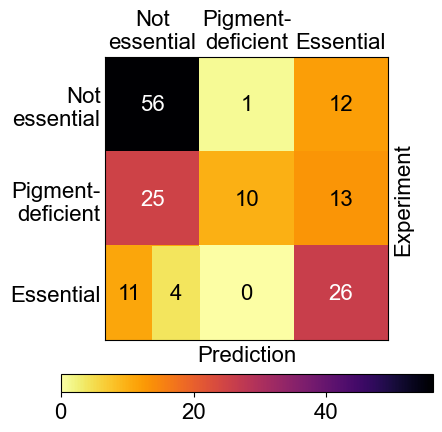

In [89]:
# plot confusion matrix
def plot_confusion_matrix(df_confusion, df_confusion2 = None, savename = None, cmap=plt.cm.gray_r, fontsize = None):
    if fontsize is not None:
        prev_fontsize = plt.rcParams['font.size']
        plt.rcParams['font.size'] = fontsize
    if not df_confusion.shape == df_confusion2.shape:
        print('Confusion matrices have different shapes, cannot plot together')
        df_confusion2 = None
    if df_confusion2 is not None:
        data2 = df_confusion2.to_numpy()
        if type(cmap) == str:
            cmap = plt.get_cmap(cmap)

    plt.figure(figsize=(6,6))
    axes_image = plt.matshow(df_confusion, cmap=cmap)
    plt.colorbar(location='bottom', pad =0.09)
    tick_marks = np.arange(len(df_confusion.columns))
    plt.tick_params(length = 0)
    plt.xticks(tick_marks, df_confusion.columns)#, rotation=45, ha='left')
    plt.yticks(tick_marks, df_confusion.index)
    plt.gca().yaxis.set_label_position("right")
    plt.ylabel(df_confusion.index.name)
    plt.xlabel(df_confusion.columns.name)

    data = df_confusion.to_numpy()
    if df_confusion2 is not None:
        data2 = df_confusion2.to_numpy()
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            # compare values of the two crosstabs, if they differ:
            if df_confusion2 is not None and data[i, j] != data2[i, j]:
                val1 = round(data[i, j], 2)
                val2 = round(data2[i, j], 2)

                # add half rectangle to the right of the cell
                color = cmap((val2 - axes_image.norm.vmin) / (axes_image.norm.vmax - axes_image.norm.vmin))
                plt.gca().add_patch(plt.Rectangle((j, i - 0.503), 0.5, 1., fill=True, facecolor=color, edgecolor=None))
                
                # add text for both values in respective half of the cell
                plt.text(j - 0.25, i, val1,
                            ha="center", va="center", color='w' if val1 > 20 else 'k')
                plt.text(j + 0.25, i, val2,
                            ha="center", va="center", color='w' if val2 > 20 else 'k')
            else:
                val = round(data[i, j], 2)
                text = plt.text(j, i, val, ha="center", va="center",
                                color='w' if val > 20 else 'k')

    if savename is not None:
        plt.savefig(savename, dpi = 400, transparent = True, bbox_inches = "tight")
    plt.show()

    if fontsize is not None:
        plt.rcParams['font.size'] = prev_fontsize

def generate_crosstab(data, order = ['Not\nessential', 'Pigment-\ndeficient', 'Essential'],
                      transl_dict = {0.: 'Not\nessential', .5: 'Pigment-\ndeficient', 1.: 'Essential'}):
    conf_data = data.copy()
    conf_data.columns = ['Experiment', 'Prediction']
    conf_data = conf_data.map(lambda x: transl_dict[x])
    return pd.crosstab(conf_data['Experiment'], conf_data['Prediction']).loc[order, order], conf_data

cm1, conf_data1 = generate_crosstab(data)
cm2, conf_data2 = generate_crosstab(data2)

# plot
plot_confusion_matrix(cm1, cm2, savename = figdir + 'nucKO_conf.png', cmap='inferno_r', fontsize = 16)

In [90]:
# show genes that remain predicted incorrectly as non-essential
data2.loc[(data2['exp model res'] == 1) & (data2['model_ess'] == 0)]

,exp model res,model_ess
Locus,,
At1g08510,1.0,0.0
At1g34430,1.0,0.0
At3g25860,1.0,0.0
At5g10330,1.0,0.0


In [91]:
# mcc with p-value estimation (Monte-Carlo, permutation test, takes a while!)
def p_str(p):
    if p <1e-3:
        return "{:.3e}".format(p)
    else:
        return round(p, 4)

alpha = 1e-2
for conf_data in [conf_data1, conf_data2]:
    mcc, mcc_p, n_it = permutation_test_mcc(conf_data['Experiment'], conf_data['Prediction'],
                                            n_permutations=int(1e10), alpha = alpha, epsilon = 1e-4)
    mam, mam_p, man_it = permutation_test_mamcc(conf_data['Experiment'], conf_data['Prediction'],
                                            n_permutations=int(1e10), alpha = alpha, epsilon = 1e-4)

    print(f'The KO predictions have a Matthews correlation coefficient (MCC) of {round(mcc, 2)} (p < {p_str(alpha)}) with the experimental results.')
    print(f'The KO predictions have a macro-averaged MCC (maM) of {round(mam, 2)} (p < {p_str(alpha)}) with the experimental results.')

The KO predictions have a Matthews correlation coefficient (MCC) of 0.39 (p < 0.01) with the experimental results.
The KO predictions have a macro-averaged MCC (maM) of 0.4 (p < 0.01) with the experimental results.
The KO predictions have a Matthews correlation coefficient (MCC) of 0.44 (p < 0.01) with the experimental results.
The KO predictions have a macro-averaged MCC (maM) of 0.45 (p < 0.01) with the experimental results.
